# Example script for usage of the API

- load the Phonon class

In [1]:
import sys, os
pwd = os.getcwd()
sys.path.append(pwd+"/..") # set to your installation path
from src.API import Phonon

- setup the Phonon object:<br><br>
The path needs to point to the file containing the phonon eigenvectors and frequencies, i.e. $phonopy.yaml$ and $qpoints.yaml$ for phonopy output, $OUTCAR$ for VASP output, or $ph.out$ for QuantumEspresso output.<br>
The output file is specified using the file parameter (for phonopy use phonopy.yaml).<br>
If effective charges are present in either $BORN$ (phonopy), $OUTCAR$ or $matdyn$, you may set the born parameter to True which enables the calculation of infrared spectra.

In this example, we will take a look at LiNbO3, a well studied ferroelectric semiconductor. The phonon calculations were performed using VASP.

In [2]:
path = pwd+"/LiNbO3"
file = "OUTCAR"
LiNbO3 = Phonon(name="LiNbO3", file=file, path=path, born=True, symprec=1.e-3, degeneracy_tolerance=5.e-2)

[__init__]: reading effective charges


- symmetry analysis<br><br>
Before we run any calculations, we are interested in the pointgroup of our system, and what types of symmetries the phononic eigenvectors at $\Gamma$ belong to. The symmetry analysis can only be performed if the FORCE_CONSTANTS file is present. This phonopy-specific file can be obtained by invoking phonopy via
```bash
phonopy -fc vasprun.xml
```
<br>

IMPORTANT: All symmetry analysis implicitly use the standard orientation of the unit cell. Make sure that your unit cell and phonon calculation were properly set up! Symmetry considerations can significantly reduce the numerical effort and will make interpretations of the resulting spectra more straightforward.

In [3]:
LiNbO3.print_pointgroup()
LiNbO3.print_decomposition()

Pointgroup:  3m
Mode decomposition at Γ
Γ = 4(A1) + 18(E) + 5(A2)



Our crystal belongs to the trigonal pointgroup 3m, and we have a total of 27 optical modes, which belong to either of three different symmetry classes. E modes are always doubly degenerate.

# IR spectroscopy
- IR selection rules<br><br>
We can check the symmetry of the dielectric tensor as well as the selection rules for IR spectroscopy. The selection rules determine which modes are observable under a given geometry setup.

In [4]:
LiNbO3.print_dielectrictensor()
LiNbO3.print_irselection()

Dielectric Tensor of point group 3m
['a' '0' '0']
['0' 'a' '0']
['0' '0' 'b']

IR selection Rules for pointgroup 3m
        | observable modes
 E || x |         E       
 E || y |         E       
 E || z |        A1       



Under E||x and E||y, only E modes are observable. Since we have 18 doubly degenerate modes of them, we can expect to see 9 peaks in this setup (assuming that peaks do not overlap and have a meaningfully large activity). Because the xx and yy components of the dielectric tensor are equivalent, the observed spectra for these two geometry setups will look exactly the same.<br>
For E||z only the A1 modes are observable. Note, that the A2 modes cannot be probed by infrared spectroscopy.<br><br>
<br><br>
The infrared spectrum is calculated by invoking

In [5]:
LiNbO3.smearing[4] = 5.0 # optionally, set individual smearing values for each mode, default is 5cm⁻1
#LiNbO3.load_ir()
LiNbO3.calc_ir()

[calcIR]: Done.


We can plot the results to a file by typing the following lines. The spectra are in pdf format and located in ```path```.

In [6]:
LiNbO3.write_ir()
LiNbO3.plot_ir()

[plotIRSpectrum]: Done.


Of course we can also plot the spectra directly in jupyter:

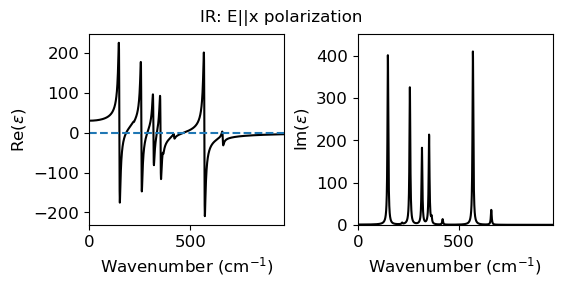

In [7]:
import matplotlib.pyplot as plt
import numpy as np

photon_freqs = LiNbO3.IR_data["x"][0]
epsr_x = np.real(LiNbO3.IR_data["x"][1])
epsi_x = np.imag(LiNbO3.IR_data["x"][1])
#epsr_y = np.real(LiNbO3.IR_data["y"][1])
#epsi_y = np.imag(LiNbO3.IR_data["y"][1])
#epsr_z = np.real(LiNbO3.IR_data["z"][1])
#epsi_z = np.imag(LiNbO3.IR_data["z"][1])

fig, ((ax1, ax2)) = plt.subplots(1,2, layout="constrained")
fig.suptitle("IR: E||x polarization")

ax1.set_xlim([photon_freqs[0], photon_freqs[-1]])
ax1.plot(photon_freqs, epsr_x, color="black", label="Real")
ax1.axhline(ls="dashed")
ax1.set_xlabel("Wavenumber (cm$^{-1}$)")
ax1.set_ylabel("Re($\\varepsilon$)")

ax2.set_xlim([photon_freqs[0], photon_freqs[-1]])
ax2.set_ylim([0, np.max(epsi_x)*1.1])
ax2.plot(photon_freqs, epsi_x, color="black", label="Imag")
ax2.set_xlabel("Wavenumber (cm$^{-1}$)")
ax2.set_ylabel("Im($\\varepsilon$)")

plt.show()

We can identify all 9 expected peaks corresponding to the E-type modes, even though some of them are very weak. Similarly, we could plot the E||z configuration to see the 4 A1 modes. The smearing can be adjusted to yield a better visual comparison to experiment, though some features might get lost. Make sure to recalculate the spectrum when adjusting the smearing parameter.<br><br>
In experiments, the reflectance is often more convenient to measure. We can also calculate and plot the reflectance in a similar manner:

[calcReflectance]: Done.
[plotReflectanceSpectrum]: Done.


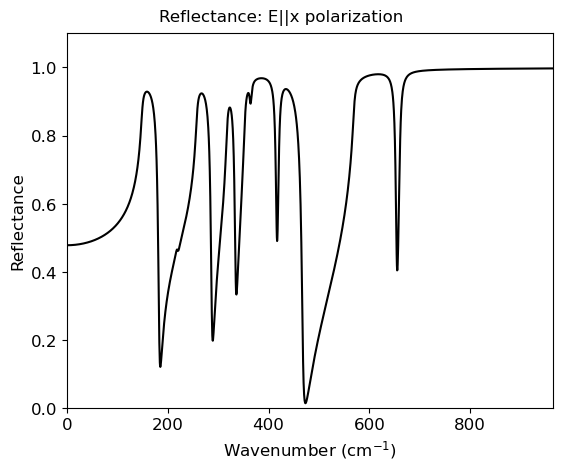

In [8]:
#LiNbO3.load_reflectance()
LiNbO3.calc_reflectance()
LiNbO3.write_reflectance()
LiNbO3.plot_reflectance()

photon_freqs = LiNbO3.reflectance_data["x"][0]
R_x = LiNbO3.reflectance_data["x"][1]
#R_y = test.reflectance_data["y"][1]
#R_z = test.reflectance_data["z"][1]

fig, ax = plt.subplots(1,1, layout="constrained")
fig.suptitle("Reflectance: E||x polarization")

ax.set_xlim([photon_freqs[0], photon_freqs[-1]])
ax.set_ylim([0, 1.1])
ax.plot(photon_freqs, R_x, color="black", label="Reflectance")
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Reflectance")

plt.show()

# Lyddane-Sachs-Teller relation

We can easily calculate the static permittivity from the Lyddane-Sachs-Teller relation, if we have effective charges and the high-frequency permittivity available. This step requires phonopy.

In [9]:
LiNbO3.calc_LST()
print(LiNbO3.eps_zero)

[[ 2.67417221e+01  1.59967867e-04  2.61640047e-05]
 [ 1.59967867e-04  2.67654028e+01 -0.00000000e+00]
 [ 2.61640047e-05 -0.00000000e+00  2.96859523e+01]]


# Raman spectroscopy
- Raman selection rules<br><br>
The selection rules for Raman spectroscopy are more complicated, since also the propagation direction of the incoming and scattered photons will be of relevance. Each Raman active phonon mode will have a distinct Raman tensor, which then in turn governs under which geometry setups the mode can be observed.

In [10]:
LiNbO3.print_ramantensors()
LiNbO3.print_ramanselection()

Raman Tensors of point group 3m
A1
['a' '0' '0']
['0' 'a' '0']
['0' '0' 'b']
E
['0' 'c' 'd']
['c' '0' '0']
['d' '0' '0']
E
['c' '0' '0']
['0' '-c' 'd']
['0' 'd' '0']

Raman selection Rules for pointgroup 3m
        |   observable modes   | tensor components
 x(yy)x̅ |    A1(TO) + E(TO)    | a^2 + c^2
 x(yz)x̅ |         E(TO)        | d^2
 x(zz)x̅ |        A1(TO)        | b^2
 y(xx)y̅ |    A1(TO) + E(LO)    | a^2 + c^2
 y(xz)y̅ |         E(TO)        | d^2
 y(zz)y̅ |        A1(TO)        | b^2
 z(xx)z̅ |    A1(LO) + E(TO)    | a^2 + c^2
 z(xy)z̅ |         E(TO)        | c^2
 z(yy)z̅ |    A1(LO) + E(TO)    | a^2 + c^2
--------------------------------------------------
 x(yx)y |       E(LO+TO)       | c^2
 x(yz)y |       E(LO+TO)       | d^2
 x(zx)y |       E(LO+TO)       | d^2
 x(zz)y |        A1(TO)        | b^2
 x(yx)z |       E(LO+TO)       | c^2
 x(yy)z |       A1(LO+TO)      | a^2
 x(zx)z |       E(LO+TO)       | d^2
 x(zy)z |         E(TO)        | d^2
 y(xx)z | A1(LO+TO) + E(LO+TO

Only the A1 and E modes are Raman active, and the A2 modes can again not be observed. The E modes are doubly degenerate, but their Raman tensors are not the same.<br>
A list of the commonly used geometry setups for backscattering and right-angle scattering are displayed above. First, we will only calculate the intensity of TO type phonon modes. As such, we choose for the propagation direction to be calculated as the $x$(..)$\bar{x}$ configurations. We provide this option in the following line:

In [11]:
LiNbO3.qdir=(1,0,0)

The variable qdir is simply a combination of the incoming and scattered propagation direction of the photons, e.g. $x$(..)$y$ configuration would be qdir=(1,1,0), $x$(..)$\bar{x}$ corresponds to (1,0,0) and so on.

In order to calculate a Raman spectrum, we have to create unit cells where the atoms are displaced along a phononic eigenvector. For each of these unit cells, a calculation has to be run to extract the electronic part of the dielectric function. Not all Raman tensors have to be explicitly calculated: Only Raman active modes need to be considered, and only one mode per degenerate pair/triplett. We can check if the script correctly sets up the modes to calculate, or change them manually if need be.

In [12]:
print(LiNbO3.labels)
print(LiNbO3.modelist)

{1: 'A2', 2: 'E', 3: 'E', 4: 'A1', 5: 'E', 6: 'E', 7: 'A2', 8: 'E', 9: 'E', 10: 'A2', 11: 'E', 12: 'E', 13: 'E', 14: 'E', 15: 'A1', 16: 'E', 17: 'E', 18: 'A2', 19: 'A1', 20: 'E', 21: 'E', 22: 'A1', 23: 'E', 24: 'E', 25: 'A2', 26: 'E', 27: 'E', 28: None, 29: None, 30: None}
[ 2  4  5  8 11 13 15 16 19 20 22 23 26]


The labels keyword stores the symmetry label of all 30 modes that have been calculated by VASP/phonopy. We see that the modelist attribute only stores the relevant modes. Since VASP orders the phonon frequencies in descending order, the last three modes in the first list correspond to acoustic modes, and hence they, as well as the A2 and one degenerate E mode per pair, are ignored.<br><br>
Now we can set up and create the unit cells with displaced atoms: We want to calculate the dielectric functions in VASP, but QuantumEspresso is also an option.

In [13]:
LiNbO3.code_out = "VASP"
LiNbO3.calc_raman_displace()

[calcDisplace]: Generating displacements...
[calcDisplace]: Done.


The cells are created in path/displacements/modeX_Y, and the dielectric function needs to be calculated for all of these file.<br><br>
After the calculations are done, we can calculate the Raman tensors.

In [14]:
#LiNbO3.load_raman_tensors()
LiNbO3.calc_raman_tensors()

[calcTensors]: Calculating Raman tensors of modes [ 2  4  5  8 11 13 15 16 19 20 22 23 26]


/home/felix/Downloads/RamanPy/src/calcTensors.py:155: RuntimeWarning: overflow encountered in scalar power
  R_degen += np.sqrt(x[k]**2+x[k+1]**2)*E[j+2*k]
/home/felix/Downloads/RamanPy/src/calcTensors.py:155: RuntimeWarning: invalid value encountered in multiply
  R_degen += np.sqrt(x[k]**2+x[k+1]**2)*E[j+2*k]


[calcTensors]: Done.


The Raman tensors of the degenerate modes are also set, and all tensors are symmetrized.<br>
Now we can calculate the Raman spectrum. Again, we set up some parameters:

In [15]:
LiNbO3.temperature = 300 # simulation temperature in Kelvin
LiNbO3.photon_freq = 2   # the photon frequency of the laser in eV
LiNbO3.smearing[4] = 5.0 # linewidth in cm⁻1, default 5.0, can be set for each mode individually
LiNbO3.stokes = "stokes" # "stokes" or "anti-stokes" scattering

#LiNbO3.load_raman_spectrum()
#LiNbO3.load_raman_tensors_const()
#LiNbO3.load_raman_intensity()
LiNbO3.calc_raman_spectrum()
LiNbO3.write_raman_spectrum()

[calcSpectrum]: Calculating Raman spectrum of modes [ 2  3  4  5  6  8  9 11 12 13 14 15 16 17 19 20 21 22 23 24 26 27]
[calcSpectrum]: Laser frequency set to 2eV
[calcSpectrum]: Temperature set to 300K
[calcSpectrum]: Done.


We can plot the spectrum in jupyter:

<function matplotlib.pyplot.show(close=None, block=None)>

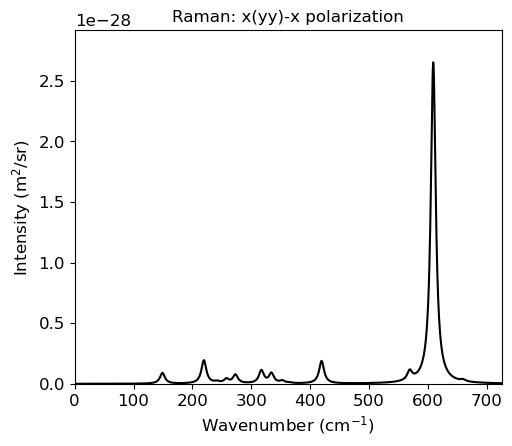

In [16]:
freq_data = LiNbO3.ramanspectrum_data["yy"][0]
yy_data = LiNbO3.ramanspectrum_data["yy"][1]

#perp_data = LiNbO3.ramanspectrum_data["perp"][1] # averaged spectrum for perpendicular geometry setup
#back_data = LiNbO3.ramanspectrum_data["back"][1] # averaged spectrum for backscattering geometry setup

ymax = np.max(yy_data)

ax = plt.subplot()
ax.plot(freq_data, yy_data, color="black", label="")
#ax.legend(fontsize=fontsize)
ax.set_title("Raman: x(yy)-x polarization")
ax.set_ylim(0, 1.1*ymax)
ax.set_xlim(freq_data[0], freq_data[-1])
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity (m$^2$/sr)", fontsize=12)
plt.show

Plots can also be created using:

In [17]:
LiNbO3.plot_raman()

[plotRamanSpectrum]: Done.


We can also create polar plots for the Raman intensity of Raman active modes, e.g. the degenerate E modes 5 and 6 and the A1 mode 15 in the xy-plane:

In [18]:
LiNbO3.plot_polar_raman(zero_axis=np.array([1,0,0]), rotation_axis=np.array([0,0,1]), modes=[15, 5, 6])

[plotPolarRaman]: modes        : [15, 5, 6]
[plotPolarRaman]: zero axis    : [1 0 0]
[plotPolarRaman]: rotation axis: [0 0 1]
[plotPolarRaman]: Done.


This also highlights the previously shown selection rules, that mode 15 (A1-type) is visible in $.(xx).$ but not $.(xy).$ configuration, while one of each degenerate pair of E-type modes is visible in either configuration.

Let's assume we instead want to simulate a Raman spectrum in $y(..)\bar{y}$ configuration. In this case, we need to account for LO-TO splitting of the E-modes (see the selection rules from previously). Phonopy provides the utility to apply a non-analytical term correction to the dynamical matrix, which will in turn yield LO phonon frequencies. The Raman tensors and ionic displacement patterns do, in a first approximation, not change. Thus, we only use phonopy to assign the LO-TO splitting and only track the change in the phonon's frequencies to get the corrected Raman spectrum. The LO correction requires that the dynamical matrix has been calculated with phonopy, and that born effective charges are present.

In [19]:
LiNbO3_LO = Phonon(file=file, path=path, born=True, qdir=(0,1,0), LOcorr=True, symprec=1.e-3, degeneracy_tolerance=5.e-2)
LiNbO3_LO.load_raman_tensors() # this function is very slow, it can be more efficient to simply recalculate the tensors
LiNbO3_LO.calc_raman_spectrum()
LiNbO3_LO.plot_raman()

[__init__]: reading effective charges
[__init__]: applying LO correction
[getLOFreqs]: Using cartesian q-direction (0, 1, 0)
[calcSpectrum]: Calculating Raman spectrum of modes [ 2  3  4  5  6  8  9 11 12 13 14 15 16 17 19 20 21 22 23 24 26 27]
[calcSpectrum]: Laser frequency set to 2.0eV
[calcSpectrum]: Temperature set to 300K
[calcSpectrum]: Done.
[plotRamanSpectrum]: Done.


<function matplotlib.pyplot.show(close=None, block=None)>

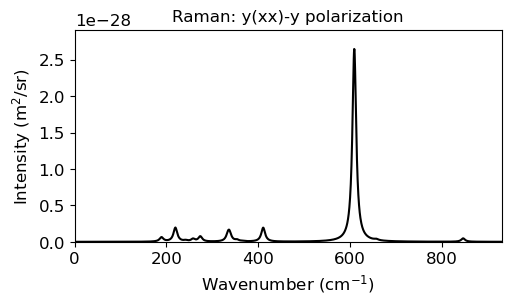

In [20]:
freq_data = LiNbO3_LO.ramanspectrum_data["xx"][0]
xx_data = LiNbO3_LO.ramanspectrum_data["xx"][1]

ymax = np.max(xx_data)

ax = plt.subplot()
ax.plot(freq_data, xx_data, color="black", label="")
#ax.legend(fontsize=fontsize)
ax.set_title("Raman: y(xx)-y polarization")
ax.set_ylim(0, 1.1*ymax)
ax.set_xlim(freq_data[0], freq_data[-1])
ax.set_xlabel("Wavenumber (cm$^{-1}$)")
ax.set_ylabel("Intensity (m$^2$/sr)", fontsize=12)
plt.show